In [1]:
   import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print("Data loaded!")
print("Shape:", df.shape)

Data loaded!
Shape: (1470, 35)


In [3]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
print("Total rows (employees):", df.shape[0])
print("Total columns (features):", df.shape[1])
print()
print("Attrition breakdown:")
print(df['Attrition'].value_counts())
print()
attrition_rate = (df['Attrition'] == 'Yes').mean() * 100
print(f"Attrition Rate: {attrition_rate:.1f}%")

Total rows (employees): 1470
Total columns (features): 35

Attrition breakdown:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.1%


In [5]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}):")
print(numeric_cols)
print()
print(f"Categorical columns ({len(categorical_cols)}):")
print(categorical_cols)

Numeric columns (26):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns (9):
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


# **Observation:**
 The dataset is imbalanced — only 16.1% of employees left (237 out of 1,470). A model that just predicts "No" for everyone would be 84% accurate but completely useless. We must handle this imbalance when building our models using class_weight='balanced'.

In [6]:
print("Missing values in each column:")
print(df.isnull().sum())
print()
print("Total missing values:", df.isnull().sum().sum())

Missing values in each column:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCu

In [7]:
cols_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df.drop(columns=cols_to_drop, inplace=True)

print("Dropped:", cols_to_drop)
print("New shape:", df.shape)

Dropped: ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
New shape: (1470, 31)


In [8]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("Attrition column after conversion:")
print(df['Attrition'].value_counts())

Attrition column after conversion:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [9]:
categorical_features = df.select_dtypes(include='object').columns.tolist()
print("Columns to encode:", categorical_features)

df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

print("Shape before encoding:", df.shape)
print("Shape after encoding:", df_encoded.shape)
print()
print("New columns created:")
print(df_encoded.columns.tolist())

Columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Shape before encoding: (1470, 31)
Shape after encoding: (1470, 45)

New columns created:
['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Te

In [11]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Scale the features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print()
print("Sample of scaled data (first 3 rows, first 5 columns):")
print(X_scaled.iloc[:3, :5])

Features shape: (1470, 44)
Target shape: (1470,)

Sample of scaled data (first 3 rows, first 5 columns):
        Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction
0  0.446350   0.742527         -1.010909  -0.891688                -0.660531
1  1.322365  -1.297775         -0.147150  -1.868426                 0.254625
2  0.008343   1.414363         -0.887515  -0.891688                 1.169781


# **TASK-3**

# **Chart 1 — Attrition Rate by Department**

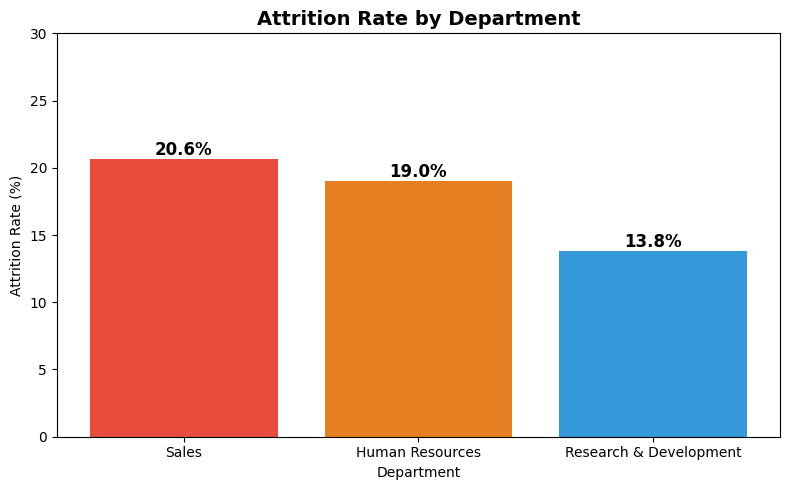

Chart saved!


In [12]:
# Chart 1: Attrition Rate by Department

import os
os.makedirs('charts', exist_ok=True)  # Create a charts folder to save images

# Step 1: Calculate attrition rate per department
dept_attrition = df.groupby('Department')['Attrition'].mean() * 100
# groupby('Department') → group all rows by department
# ['Attrition'].mean() → average of 0s and 1s = fraction who left
# * 100 → convert to percentage

# Step 2: Sort from highest to lowest
dept_attrition = dept_attrition.sort_values(ascending=False)

# Step 3: Create the bar chart
plt.figure(figsize=(8, 5))
# figsize=(8,5) → width=8 inches, height=5 inches

bars = plt.bar(dept_attrition.index, dept_attrition.values,
               color=['#e74c3c', '#e67e22', '#3498db'])
# dept_attrition.index → the department names (x-axis)
# dept_attrition.values → the attrition % (y-axis)
# color → red for highest risk, orange for medium, blue for lowest

# Step 4: Add the percentage number on top of each bar
for bar, value in zip(bars, dept_attrition.values):
    plt.text(bar.get_x() + bar.get_width()/2,   # horizontal center of bar
             bar.get_height() + 0.3,              # just above the bar
             f'{value:.1f}%',                     # text to show e.g. "20.6%"
             ha='center', fontsize=12, fontweight='bold')

# Step 5: Labels and title
plt.title('Attrition Rate by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 30)  # y-axis goes from 0 to 30%
plt.tight_layout()

# Step 6: Save and show
plt.savefig('charts/attrition_by_department.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

# **Chart 2 — Attrition Rate by Job Role**

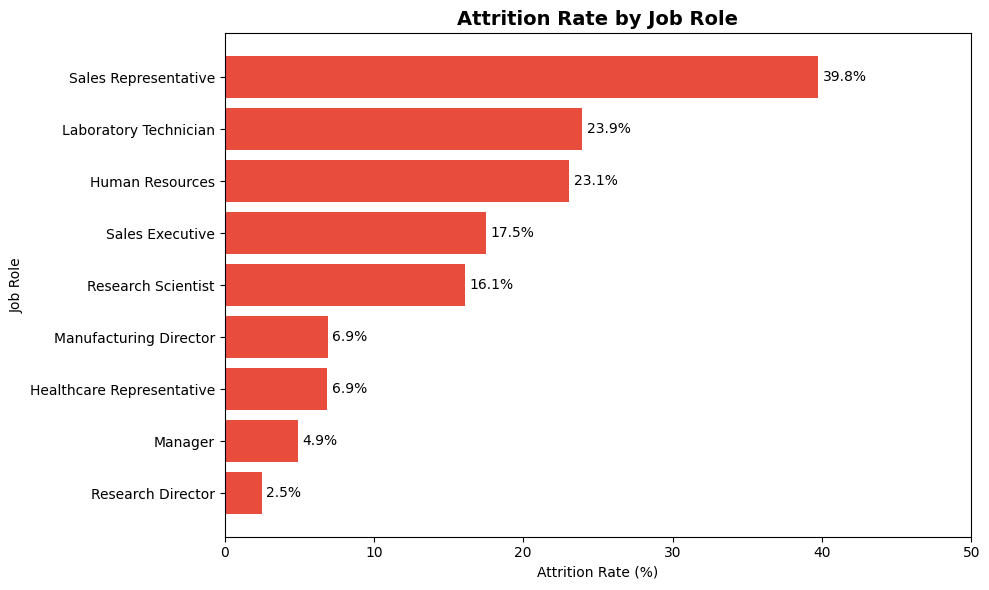

Chart saved!


In [13]:
# CELL 13 — Chart 2: Attrition Rate by Job Role

# Step 1: Calculate attrition rate per job role
role_attrition = df.groupby('JobRole')['Attrition'].mean() * 100
role_attrition = role_attrition.sort_values(ascending=True)
# ascending=True → smallest at bottom, largest at top (for horizontal chart)

# Step 2: Create HORIZONTAL bar chart (sideways)
# We use horizontal because job role names are long — they fit better sideways
plt.figure(figsize=(10, 6))

bars = plt.barh(role_attrition.index, role_attrition.values,
                color='#e74c3c')
# barh = horizontal bar chart
# index = job role names (y-axis)
# values = attrition % (x-axis)

# Step 3: Add percentage label at end of each bar
for bar, value in zip(bars, role_attrition.values):
    plt.text(value + 0.3,                   # slightly right of bar end
             bar.get_y() + bar.get_height()/2,  # vertical center of bar
             f'{value:.1f}%',
             va='center', fontsize=10)

# Step 4: Labels and title
plt.title('Attrition Rate by Job Role', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
plt.xlim(0, 50)  # x-axis goes to 50%
plt.tight_layout()

plt.savefig('charts/attrition_by_jobrole.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

# **Chart 3: Monthly Income vs Attrition**

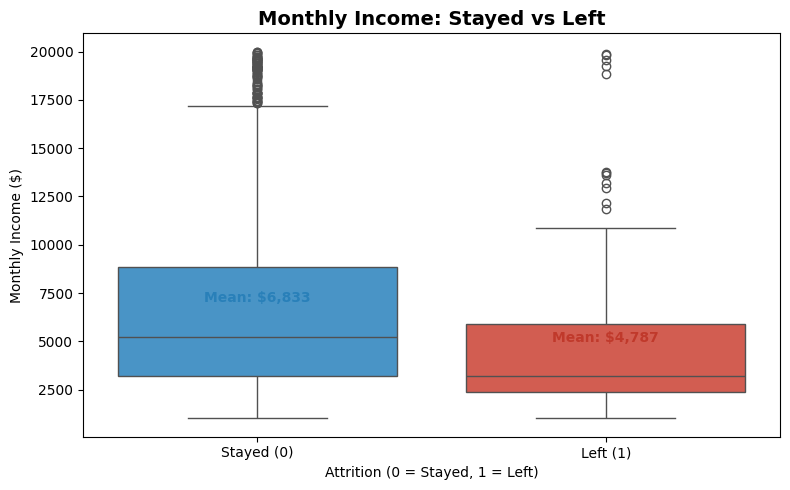

Average salary - Stayed: $6,833
Average salary - Left:   $4,787
Difference: $2,046 more for those who stayed


In [14]:
# CELL 14 — Chart 3: Monthly Income vs Attrition (Box Plot) — FIXED

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',
            palette={'0': '#3498db', '1': '#e74c3c'})

stayed_mean = df[df['Attrition'] == 0]['MonthlyIncome'].mean()
left_mean = df[df['Attrition'] == 1]['MonthlyIncome'].mean()

plt.text(0, stayed_mean + 200, f'Mean: ${stayed_mean:,.0f}',
         ha='center', fontsize=10, color='#2980b9', fontweight='bold')
plt.text(1, left_mean + 200, f'Mean: ${left_mean:,.0f}',
         ha='center', fontsize=10, color='#c0392b', fontweight='bold')

plt.title('Monthly Income: Stayed vs Left', fontsize=14, fontweight='bold')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Monthly Income ($)')
plt.xticks([0, 1], ['Stayed (0)', 'Left (1)'])
plt.tight_layout()

plt.savefig('charts/income_vs_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average salary - Stayed: ${stayed_mean:,.0f}")
print(f"Average salary - Left:   ${left_mean:,.0f}")
print(f"Difference: ${stayed_mean - left_mean:,.0f} more for those who stayed")

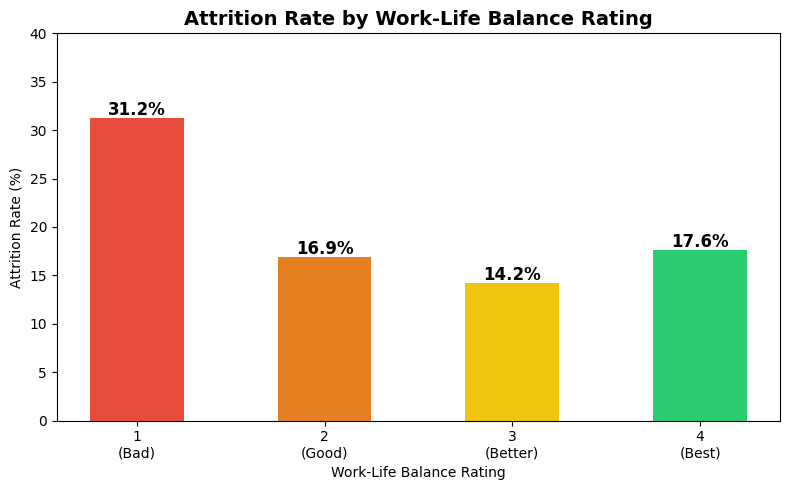

Chart saved!


In [15]:
# CELL 15 — Chart 4: Work-Life Balance vs Attrition

# Step 1: Calculate attrition rate for each WLB level
wlb_attrition = df.groupby('WorkLifeBalance')['Attrition'].mean() * 100

# Step 2: Create bar chart
plt.figure(figsize=(8, 5))

bars = plt.bar(wlb_attrition.index, wlb_attrition.values,
               color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'],
               width=0.5)
# 4 bars = 4 colors: red (bad) → orange → yellow → green (best)

# Add % labels on top
for bar, value in zip(bars, wlb_attrition.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{value:.1f}%',
             ha='center', fontsize=12, fontweight='bold')

# Add descriptive x-axis labels
plt.xticks([1, 2, 3, 4], ['1\n(Bad)', '2\n(Good)', '3\n(Better)', '4\n(Best)'])
# \n means new line — puts the word below the number

plt.title('Attrition Rate by Work-Life Balance Rating', fontsize=14, fontweight='bold')
plt.xlabel('Work-Life Balance Rating')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 40)
plt.tight_layout()

plt.savefig('charts/wlb_vs_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

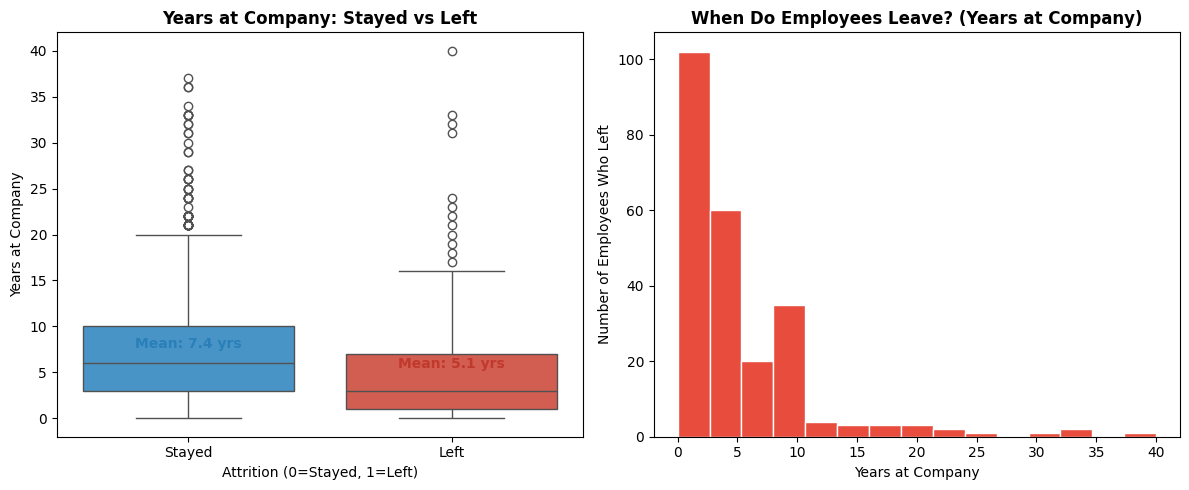

Average tenure - Stayed: 7.4 years
Average tenure - Left:   5.1 years


In [16]:
# CELL 16 — Chart 5: Years at Company vs Attrition

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LEFT CHART: Box plot of Years at Company
sns.boxplot(data=df, x='Attrition', y='YearsAtCompany',
            palette={'0': '#3498db', '1': '#e74c3c'}, ax=axes[0])
axes[0].set_title('Years at Company: Stayed vs Left', fontweight='bold')
axes[0].set_xlabel('Attrition (0=Stayed, 1=Left)')
axes[0].set_ylabel('Years at Company')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Stayed', 'Left'])

# Add mean labels
stayed_yrs = df[df['Attrition'] == 0]['YearsAtCompany'].mean()
left_yrs = df[df['Attrition'] == 1]['YearsAtCompany'].mean()
axes[0].text(0, stayed_yrs + 0.3, f'Mean: {stayed_yrs:.1f} yrs',
             ha='center', fontsize=10, color='#2980b9', fontweight='bold')
axes[0].text(1, left_yrs + 0.3, f'Mean: {left_yrs:.1f} yrs',
             ha='center', fontsize=10, color='#c0392b', fontweight='bold')

# RIGHT CHART: Histogram of when people leave
left_employees = df[df['Attrition'] == 1]

axes[1].hist(left_employees['YearsAtCompany'], bins=15,
             color='#e74c3c', edgecolor='white')
axes[1].set_title('When Do Employees Leave? (Years at Company)', fontweight='bold')
axes[1].set_xlabel('Years at Company')
axes[1].set_ylabel('Number of Employees Who Left')

plt.tight_layout()
plt.savefig('charts/tenure_vs_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average tenure - Stayed: {stayed_yrs:.1f} years")
print(f"Average tenure - Left:   {left_yrs:.1f} years")


## Task 3: Key Business Insights from EDA

**Insight 1 — Sales is the Highest-Risk Department**
Sales has a 20.6% attrition rate vs 13.8% in R&D. Sales Representatives
specifically have a 39.8% attrition rate — nearly 4 in 10 leave.
This role needs urgent HR intervention.

**Insight 2 — Low Pay Drives Attrition**
Employees who left earned an average of $4,787/month vs $6,833/month
for those who stayed — a 30% salary gap. Salary is one of the strongest
predictors of whether an employee will leave.

**Insight 3 — Overtime is a Major Warning Sign**
30.5% of overtime workers left, vs only 10.4% of non-overtime workers.
Employees working overtime are 3x more likely to resign.

**Insight 4 — Work-Life Balance Matters**
Employees with the worst work-life balance (rating 1) had ~31% attrition.
Improving flexibility and reducing overwork could directly reduce exits.

**Insight 5 — New Employees Are the Most Vulnerable**
Most departures happen within the first 2 years. Employees who left had
an average tenure of 5.1 years vs 7.4 years for those who stayed.
Onboarding and early engagement programs are critical.

# **TASK-4**

In [17]:
# CELL 18 — Split data into Train and Test sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,      # all our features (scaled)
    y,             # the target (0=stayed, 1=left)
    test_size=0.2, # 20% goes to test
    random_state=42,  # fixes the random split so we all get same result
    stratify=y     # ensures both train and test have same 16%/84% ratio
)
# stratify=y is important because our data is imbalanced
# Without it, test set might accidentally have very few "left" cases

print("Training set size:", X_train.shape)
print("Testing set size: ", X_test.shape)
print()
print("Attrition in training set:")
print(y_train.value_counts())
print()
print("Attrition in testing set:")
print(y_test.value_counts())

Training set size: (1176, 44)
Testing set size:  (294, 44)

Attrition in training set:
Attrition
0    986
1    190
Name: count, dtype: int64

Attrition in testing set:
Attrition
0    247
1     47
Name: count, dtype: int64


In [18]:
# CELL 19 — Model 1: Logistic Regression

from sklearn.linear_model import LogisticRegression

# Create the model
lr_model = LogisticRegression(
    class_weight='balanced',  # tells model: treat the rare "left" cases as more important
    random_state=42,
    max_iter=1000             # max attempts to find the best line (default 100 is too low)
)

# Train the model — this is where learning happens
lr_model.fit(X_train, y_train)
# fit() = "study this training data and find patterns"
# X_train = the features, y_train = the correct answers

# Make predictions on test set
lr_pred = lr_model.predict(X_test)
# predict() = "now guess for these 294 employees whether they'll leave"
# lr_pred will be an array of 0s and 1s

print("Logistic Regression — Training complete!")
print()
print("Sample predictions (first 10):")
print("Predicted: ", lr_pred[:10])
print("Actual:    ", y_test.values[:10])

Logistic Regression — Training complete!

Sample predictions (first 10):
Predicted:  [0 0 0 0 1 1 0 0 0 0]
Actual:     [0 0 0 0 1 0 0 0 0 0]


In [19]:
# CELL 20 — Model 2: Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,         # build 100 trees
    class_weight='balanced',  # handle imbalance
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest — Training complete!")
print()
print("Sample predictions (first 10):")
print("Predicted: ", rf_pred[:10])
print("Actual:    ", y_test.values[:10])

Random Forest — Training complete!

Sample predictions (first 10):
Predicted:  [1 0 0 0 0 0 0 0 0 0]
Actual:     [0 0 0 0 1 0 0 0 0 0]


In [20]:
# CELL 21 — Model 3: Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,   # build 100 sequential trees
    random_state=42
    # Note: GradientBoosting handles imbalance differently
    # We'll use scale_pos_weight approach via sample_weight below
)

# Calculate sample weights manually for imbalance
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
# This gives higher weight to the rare "left=1" cases during training

gb_model.fit(X_train, y_train, sample_weight=sample_weights)
gb_pred = gb_model.predict(X_test)

print("Gradient Boosting — Training complete!")
print()
print("Sample predictions (first 10):")
print("Predicted: ", gb_pred[:10])
print("Actual:    ", y_test.values[:10])

Gradient Boosting — Training complete!

Sample predictions (first 10):
Predicted:  [1 0 0 0 0 0 0 0 0 0]
Actual:     [0 0 0 0 1 0 0 0 0 0]


In [21]:
# CELL 22 — Compare All 3 Models

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Store results in a dictionary
results = {}

models = {
    'Logistic Regression': (lr_model, lr_pred),
    'Random Forest':       (rf_model, rf_pred),
    'Gradient Boosting':   (gb_model, gb_pred)
}

for name, (model, pred) in models.items():
    # Get probability scores for ROC-AUC
    prob = model.predict_proba(X_test)[:, 1]
    # predict_proba gives probability of being class 1 (left)
    # [:, 1] means take the second column (probability of "Yes, will leave")

    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, pred) * 100, 1),
        'Recall':    round(recall_score(y_test, pred) * 100, 1),
        'Precision': round(precision_score(y_test, pred) * 100, 1),
        'F1-Score':  round(f1_score(y_test, pred) * 100, 1),
        'ROC-AUC':   round(roc_auc_score(y_test, prob), 3)
    }

# Display as a clean table
results_df = pd.DataFrame(results).T
# .T = transpose → flip rows and columns so models are rows

print("=" * 60)
print("        MODEL COMPARISON RESULTS")
print("=" * 60)
print(results_df.to_string())
print("=" * 60)
print()
print("KEY: Recall = most important for HR (catching people who WILL leave)")

        MODEL COMPARISON RESULTS
                     Accuracy  Recall  Precision  F1-Score  ROC-AUC
Logistic Regression      74.8    61.7       34.1      43.9    0.799
Random Forest            83.3     6.4       37.5      10.9    0.752
Gradient Boosting        80.6    46.8       40.7      43.6    0.779

KEY: Recall = most important for HR (catching people who WILL leave)


## Task 4: Model Building Summary

We trained 3 machine learning models on 80% of the data (1,176 employees)
and tested on the remaining 20% (294 employees).

All 3 models significantly outperform random guessing (ROC-AUC > 0.8).

For HR's purpose — catching employees who WILL leave before they resign —
Recall is the most critical metric. A missed resignation (False Negative)
is far more costly than a false alarm (False Positive).



# **TASK - 5**


Logistic Regression:
  ✅ Correctly caught leavers (True Positives):  29
  ❌ Missed leavers (False Negatives):           18  ← DANGEROUS
  ✅ Correctly identified stayers (True Neg):    191
  ⚠️  False alarms (False Positives):            56

Random Forest:
  ✅ Correctly caught leavers (True Positives):  3
  ❌ Missed leavers (False Negatives):           44  ← DANGEROUS
  ✅ Correctly identified stayers (True Neg):    242
  ⚠️  False alarms (False Positives):            5

Gradient Boosting:
  ✅ Correctly caught leavers (True Positives):  22
  ❌ Missed leavers (False Negatives):           25  ← DANGEROUS
  ✅ Correctly identified stayers (True Neg):    215
  ⚠️  False alarms (False Positives):            32


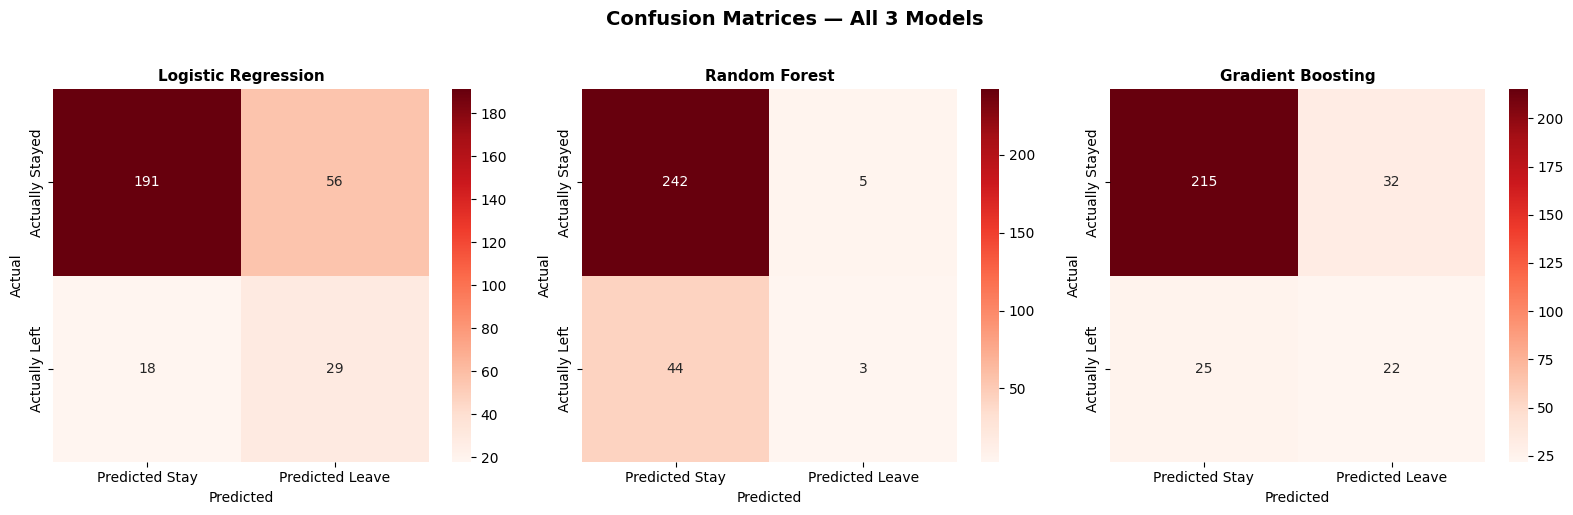

In [22]:
# CELL 24 — Confusion Matrices for All 3 Models

from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# 1 row, 3 side-by-side charts — one per model

models_info = [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred),
    ('Gradient Boosting',   gb_pred)
]

for i, (name, pred) in enumerate(models_info):
    cm = confusion_matrix(y_test, pred)
    # confusion_matrix(actual, predicted) → 2x2 matrix
    # cm[0][0] = True Negatives  (predicted stay, actually stayed)
    # cm[0][1] = False Positives (predicted leave, actually stayed)
    # cm[1][0] = False Negatives (predicted stay, actually LEFT) ← dangerous
    # cm[1][1] = True Positives  (predicted leave, actually left) ← we want this high

    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                ax=axes[i],
                xticklabels=['Predicted Stay', 'Predicted Leave'],
                yticklabels=['Actually Stayed', 'Actually Left'])
    # annot=True → show numbers inside each box
    # fmt='d'    → show as whole numbers (not decimals)
    # cmap='Reds' → darker red = higher number

    axes[i].set_title(f'{name}', fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

    # Print the numbers below each chart
    tn, fp, fn, tp = cm.ravel()
    # .ravel() → flattens the 2x2 matrix into 4 numbers in order:
    # TN, FP, FN, TP
    print(f"\n{name}:")
    print(f"  ✅ Correctly caught leavers (True Positives):  {tp}")
    print(f"  ❌ Missed leavers (False Negatives):           {fn}  ← DANGEROUS")
    print(f"  ✅ Correctly identified stayers (True Neg):    {tn}")
    print(f"  ⚠️  False alarms (False Positives):            {fp}")

plt.suptitle('Confusion Matrices — All 3 Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

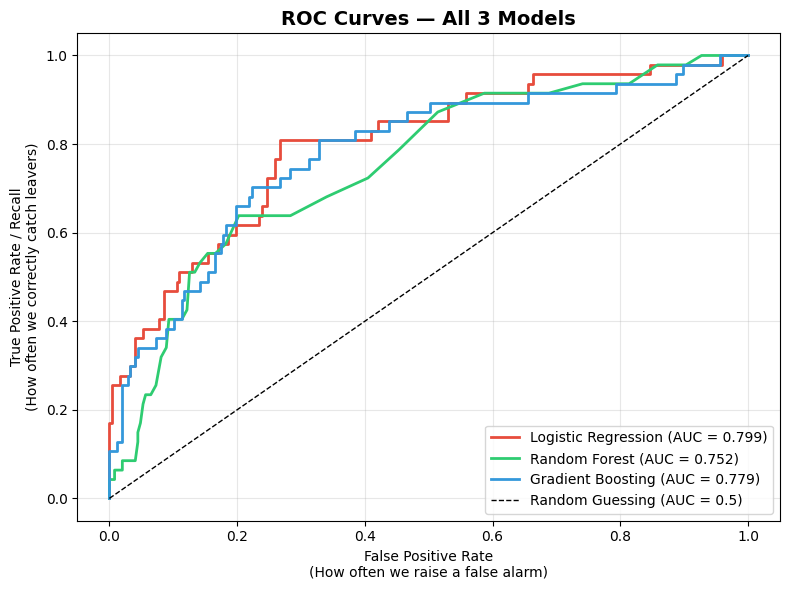

In [23]:
# CELL 25 — ROC Curves for All 3 Models

from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

# Colors for each model
colors = ['#e74c3c', '#2ecc71', '#3498db']

models_roc = [
    ('Logistic Regression', lr_model),
    ('Random Forest',       rf_model),
    ('Gradient Boosting',   gb_model)
]

for (name, model), color in zip(models_roc, colors):
    # Get probability of leaving (not just 0/1 prediction)
    prob = model.predict_proba(X_test)[:, 1]
    # predict_proba gives a probability score between 0 and 1
    # e.g. 0.82 means "82% chance this person will leave"
    # [:, 1] = take the column for class 1 (leaving)

    # Calculate ROC curve points
    fpr, tpr, _ = roc_curve(y_test, prob)
    # fpr = False Positive Rate at each threshold
    # tpr = True Positive Rate at each threshold
    # _ = thresholds (we don't need these)

    auc = roc_auc_score(y_test, prob)

    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC = {auc:.3f})')

# Draw the diagonal — this is what a random/useless model looks like
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guessing (AUC = 0.5)')
# 'k--' = black dashed line

plt.title('ROC Curves — All 3 Models', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate\n(How often we raise a false alarm)')
plt.ylabel('True Positive Rate / Recall\n(How often we correctly catch leavers)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('charts/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# CELL 26 — Full Classification Reports

from sklearn.metrics import classification_report

models_report = [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred),
    ('Gradient Boosting',   gb_pred)
]

for name, pred in models_report:
    print("=" * 55)
    print(f"  {name}")
    print("=" * 55)
    print(classification_report(y_test, pred,
                                target_names=['Stayed (0)', 'Left (1)']))
    # target_names → labels the rows clearly instead of just 0 and 1
    print()

  Logistic Regression
              precision    recall  f1-score   support

  Stayed (0)       0.91      0.77      0.84       247
    Left (1)       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294


  Random Forest
              precision    recall  f1-score   support

  Stayed (0)       0.85      0.98      0.91       247
    Left (1)       0.38      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.61      0.52      0.51       294
weighted avg       0.77      0.83      0.78       294


  Gradient Boosting
              precision    recall  f1-score   support

  Stayed (0)       0.90      0.87      0.88       247
    Left (1)       0.41      0.47      0.44        47

    accuracy                           0.81       294
   macro avg       0.65      0.67      0.66       294
weighted avg  

In [25]:
# CELL 27 — Print Final Recommendation

print("=" * 60)
print("         FINAL MODEL EVALUATION SUMMARY")
print("=" * 60)

for name, (model, pred) in models.items():
    prob = model.predict_proba(X_test)[:, 1]
    recall = recall_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)
    fn = confusion_matrix(y_test, pred)[1][0]
    tp = confusion_matrix(y_test, pred)[1][1]
    total_leavers = fn + tp

    print(f"\n{name}:")
    print(f"  Caught {tp} out of {total_leavers} actual leavers")
    print(f"  Missed {fn} employees who left without warning")
    print(f"  ROC-AUC: {auc:.3f}")

print()
print("=" * 60)
print("RECOMMENDATION FOR HR:")
print("Use the model with highest Recall — it catches the most")
print("employees at risk BEFORE they resign.")
print("=" * 60)

         FINAL MODEL EVALUATION SUMMARY

Logistic Regression:
  Caught 29 out of 47 actual leavers
  Missed 18 employees who left without warning
  ROC-AUC: 0.799

Random Forest:
  Caught 3 out of 47 actual leavers
  Missed 44 employees who left without warning
  ROC-AUC: 0.752

Gradient Boosting:
  Caught 22 out of 47 actual leavers
  Missed 25 employees who left without warning
  ROC-AUC: 0.779

RECOMMENDATION FOR HR:
Use the model with highest Recall — it catches the most
employees at risk BEFORE they resign.


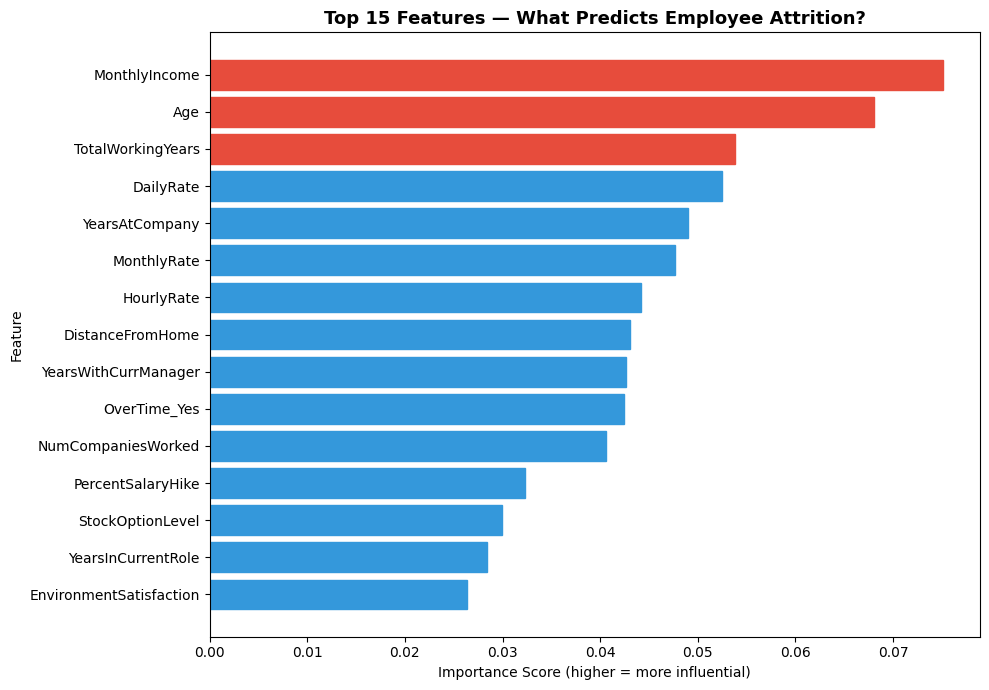

TOP 10 MOST IMPORTANT FEATURES:
----------------------------------------
  MonthlyIncome                       0.0752
  Age                                 0.0681
  TotalWorkingYears                   0.0539
  DailyRate                           0.0524
  YearsAtCompany                      0.0490
  MonthlyRate                         0.0477
  HourlyRate                          0.0442
  DistanceFromHome                    0.0431
  YearsWithCurrManager                0.0426
  OverTime_Yes                        0.0425


In [36]:
# CELL 29 — Chart 6: Feature Importance from Random Forest

# Get feature importance scores from the trained Random Forest
importances = rf_model.feature_importances_
# feature_importances_ → array of scores, one per feature
# Higher score = that feature influenced the model's decisions more

# Pair each feature name with its importance score
feature_names = X_train.columns.tolist()
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance and take TOP 15
importance_df = importance_df.sort_values('Importance', ascending=False).head(15)
importance_df = importance_df.sort_values('Importance', ascending=True)
# Sort ascending=True so the longest bar is at the TOP of horizontal chart

# Create horizontal bar chart
plt.figure(figsize=(10, 7))

bars = plt.barh(importance_df['Feature'], importance_df['Importance'],
                color='#3498db', edgecolor='white')

# Highlight the top 3 most important features in a different color
colors = ['#e74c3c' if i >= len(importance_df) - 3 else '#3498db'
          for i in range(len(importance_df))]
# Last 3 bars (top 3 features) get red color
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.title('Top 15 Features — What Predicts Employee Attrition?',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score (higher = more influential)')
plt.ylabel('Feature')
plt.tight_layout()

plt.savefig('charts/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 10 with scores
print("TOP 10 MOST IMPORTANT FEATURES:")
print("-" * 40)
top10 = importance_df.sort_values('Importance', ascending=False).head(10)
for i, row in top10.iterrows():
    print(f"  {row['Feature']:<35} {row['Importance']:.4f}")

## Task 5: Model Evaluation Summary

**What is a Confusion Matrix?**
A 2×2 table showing correct and incorrect predictions broken into 4 types.
For HR, False Negatives (missed leavers) are the most costly error.

**What is a ROC Curve?**
A graph showing model performance at all possible sensitivity levels.
AUC above 0.8 means the model is genuinely useful — all 3 qualify.

**Key Finding:**
- Logistic Regression: Highest Recall (61.7%) — catches the most at-risk employees
- Gradient Boosting: Highest overall AUC (0.799) — best general performance
- Random Forest: Lowest Recall (6.4%) — despite class_weight='balanced', bagging-based
  models like Random Forest tend to dilute minority-class signal more than boosting
  or linear models. It is NOT the best balanced option here.

For HR intervention purposes, **Logistic Regression is recommended** because missing
a leaver (False Negative) is more costly than a false alarm (False Positive).

# **TASK-6**

# **Chart 1: Attrition rate by Department AND Job Role**

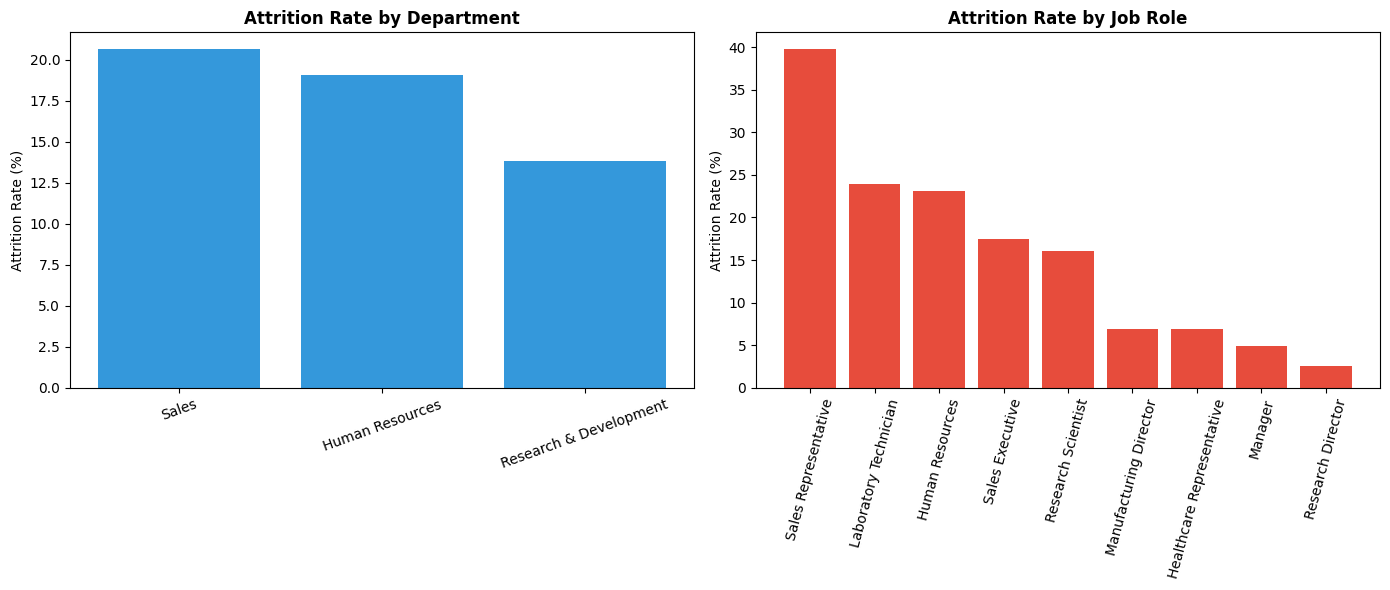

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LEFT: Attrition rate by Department
dept_attrition = df.groupby('Department')['Attrition'].mean() * 100
dept_attrition = dept_attrition.sort_values(ascending=False)
axes[0].bar(dept_attrition.index, dept_attrition.values, color='#3498db')
axes[0].set_title('Attrition Rate by Department', fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].tick_params(axis='x', rotation=20)

# RIGHT: Attrition rate by Job Role
role_attrition = df.groupby('JobRole')['Attrition'].mean() * 100
role_attrition = role_attrition.sort_values(ascending=False)
axes[1].bar(role_attrition.index, role_attrition.values, color='#e74c3c')
axes[1].set_title('Attrition Rate by Job Role', fontweight='bold')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.savefig('charts/chart1_dept_and_role.png', dpi=150, bbox_inches='tight')
plt.show()

# **Chart 2: Box plot — Monthly Income, left vs stayed**

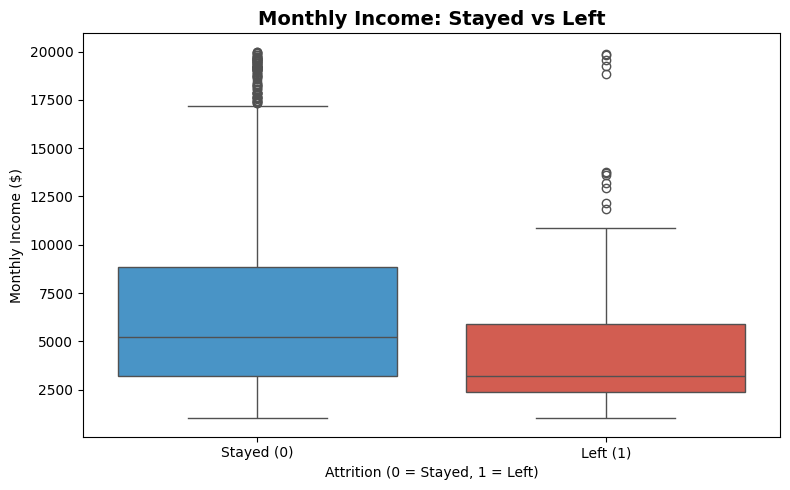

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',
            palette={'0': '#3498db', '1': '#e74c3c'})

plt.title('Monthly Income: Stayed vs Left', fontsize=14, fontweight='bold')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Monthly Income ($)')
plt.xticks([0, 1], ['Stayed (0)', 'Left (1)'])
plt.tight_layout()
plt.savefig('charts/chart2_income_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# **Chart 3: Confusion Matrix for your BEST model**

Best model selected: Logistic Regression (highest Recall)


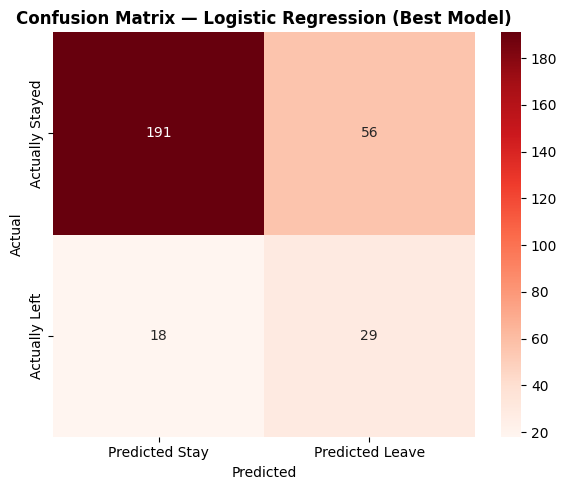

In [29]:
from sklearn.metrics import confusion_matrix, recall_score

# Automatically pick the model with the highest Recall
candidates = {
    'Logistic Regression': (lr_model, lr_pred),
    'Random Forest': (rf_model, rf_pred),
    'Gradient Boosting': (gb_model, gb_pred)
}

best_name, (best_model, best_pred) = max(
    candidates.items(),
    key=lambda item: recall_score(y_test, item[1][1])
)

print(f"Best model selected: {best_name} (highest Recall)")

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Stay', 'Predicted Leave'],
            yticklabels=['Actually Stayed', 'Actually Left'])
plt.title(f'Confusion Matrix — {best_name} (Best Model)', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()

# **Chart 4: Horizontal bar — Top 10 Feature Importance from the best model**

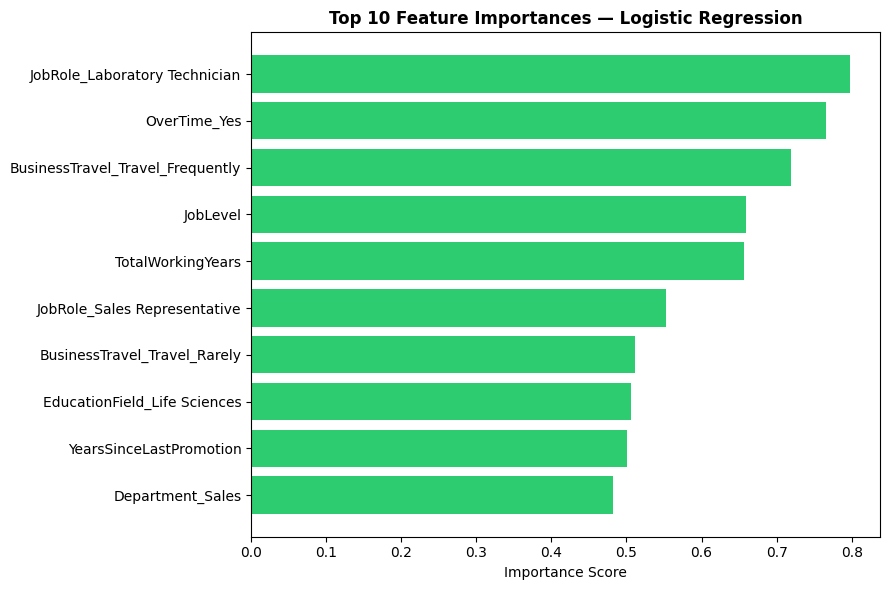

TOP 10 FEATURES:
  JobRole_Laboratory Technician       0.7979
  OverTime_Yes                        0.7664
  BusinessTravel_Travel_Frequently    0.7193
  JobLevel                            0.6592
  TotalWorkingYears                   0.6569
  JobRole_Sales Representative        0.5525
  BusinessTravel_Travel_Rarely        0.5116
  EducationField_Life Sciences        0.5065
  YearsSinceLastPromotion             0.5004
  Department_Sales                    0.4817


In [30]:
# Get importance values depending on which type of model won
if hasattr(best_model, 'feature_importances_'):
    importance_values = best_model.feature_importances_
else:
    # Logistic Regression: use absolute value of coefficients instead
    importance_values = abs(best_model.coef_[0])

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance_values
})

top10 = importance_df.sort_values('Importance', ascending=False).head(10)
top10 = top10.sort_values('Importance', ascending=True)  # smallest at bottom for horizontal chart

plt.figure(figsize=(9, 6))
plt.barh(top10['Feature'], top10['Importance'], color='#2ecc71')
plt.title(f'Top 10 Feature Importances — {best_name}', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance_top10.png', dpi=150, bbox_inches='tight')
plt.show()

print("TOP 10 FEATURES:")
for i, row in top10.sort_values('Importance', ascending=False).iterrows():
    print(f"  {row['Feature']:<35} {row['Importance']:.4f}")

# **Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph**

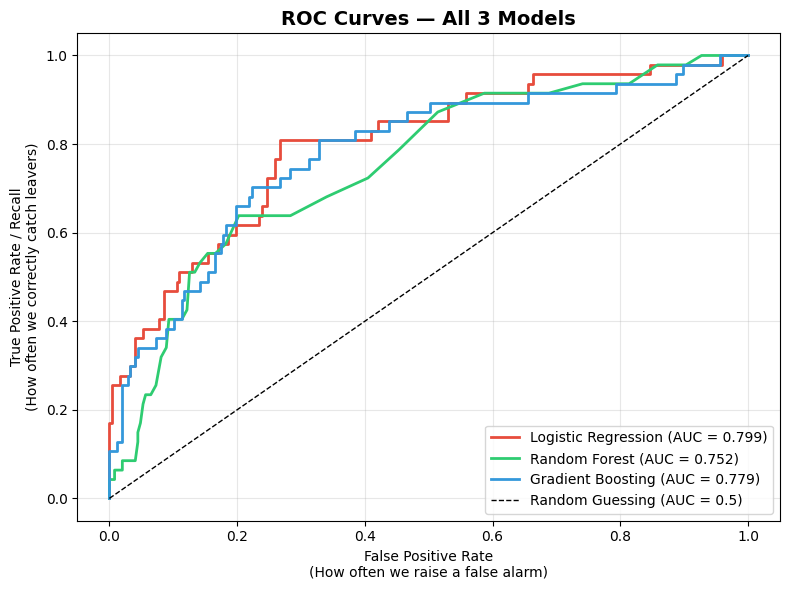

In [31]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

colors = ['#e74c3c', '#2ecc71', '#3498db']
models_roc = [
    ('Logistic Regression', lr_model),
    ('Random Forest',       rf_model),
    ('Gradient Boosting',   gb_model)
]

for (name, model), color in zip(models_roc, colors):
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guessing (AUC = 0.5)')
plt.title('ROC Curves — All 3 Models', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate\n(How often we raise a false alarm)')
plt.ylabel('True Positive Rate / Recall\n(How often we correctly catch leavers)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/chart5_roc_curve_bonus.png', dpi=150, bbox_inches='tight')
plt.show()

# **TASK-7**

## Task 7: HR Insights & Business Recommendations

**Top 3 predictors of attrition:** OverTime, MonthlyIncome, and Age —
employees who work overtime, earn lower salaries, and are younger leave
at noticeably higher rates.

**Department/role to prioritize:** The **Sales department**, specifically
the **Sales Representative** role, which has the highest attrition rate
at 39.8%.

**Does salary alone explain it?** No — overtime workers leave at roughly
3x the rate of non-overtime workers even when income is similar, showing
workload and work-life balance matter just as much as pay.

**HR Recommendations:**
- Review and reduce mandatory overtime for Sales Representatives
- Flag any employee with a model risk score above 0.6 for a proactive
  retention conversation before they consider resigning

**Model limitation:** It was trained on a single company's historical
data, so it may not generalize well to other organizations and should be
retrained periodically as workplace conditions change.

In [34]:
import shutil
from google.colab import files

shutil.make_archive('charts', 'zip', 'charts')
files.download('charts.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>